In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [341]:
rng = np.random.default_rng(seed=40)
mean = [2,-2]
cov = [[1,0],
       [0,5]]
sample = rng.multivariate_normal(mean, cov, size=int(500))

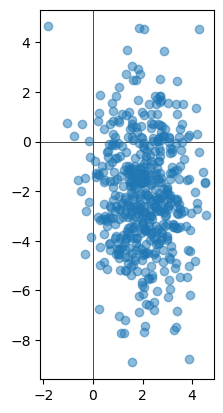

In [342]:
fig,ax = plt.subplots()
ax.scatter(sample[:,0], sample[:,1], zorder=2, alpha=0.5)
ax.axvline(c='black', linewidth=1/2, zorder=0)
ax.axhline(c='black', linewidth=1/2, zorder=0)

ax.set_aspect('equal')

In [343]:
df = pd.DataFrame(sample, columns=['x','y'])
x_bar, sigma = df.mean(), df.std()


In [344]:
### numpy covariance method ###
_x = df.x.values
_y = df.y.values

df_arr = np.stack([_x,_y], axis=0)
np.cov(df_arr)

array([[ 1.06427491, -0.09536653],
       [-0.09536653,  5.11953891]])

In [345]:
### calculate covariance ###
mean_xy = df.mean().values

delta_mean_x = df.x.values - df.x.mean()
delta_mean_y = df.y.values - df.y.mean()
# diagonals
x_var = (delta_mean_x**2).sum()/(len(df)-1)
y_var = (delta_mean_y**2).sum()/(len(df)-1)
# off-diagonals
xy_cov = (delta_mean_x * delta_mean_y).sum()/(len(df-1))

cov_mat = np.array([[x_var, xy_cov], 
                    [xy_cov, y_var]])

print("CovMat: \n", cov_mat)

### covariance angle ###
eigs = np.linalg.eig(cov_mat)
_ind = np.argmax(eigs.eigenvalues)
print(f"Prin Comp: {_ind}")
prin_comp = eigs.eigenvectors[_ind]
theta = np.arctan2(prin_comp[1], prin_comp[0])

CovMat: 
 [[ 1.06427491 -0.0951758 ]
 [-0.0951758   5.11953891]]
Prin Comp: 1


In [346]:
print(f"ANGLE: {np.degrees(theta)} [deg]")

ANGLE: -91.34372797253255 [deg]


#### CI = x_bar +/- z(s/sqrt(n))

In [347]:
alpha = 1e-3
deg_f = len(df) - 1
upper = stats.t.ppf(1 - alpha/2, df=deg_f)
lower = stats.t.ppf(alpha/2, df=deg_f)

In [348]:
lower, upper

(np.float64(-3.3101305703950064), np.float64(3.310130570395038))

In [349]:
conf_ints = {}
for c,i in enumerate(x_bar):
    _upper = x_bar[c] + upper*(sigma[c]/np.sqrt(len(df)))
    _lower = x_bar[c] + lower*(sigma[c]/np.sqrt(len(df)))

    #print(c, " ", _upper, " ", _lower, " ", _upper - _lower)
    conf_ints[c] = [_lower, _upper]

conf_ints

/var/folders/jg/f0kfj8pd3hx6_7c7z6q0nsfr0000gn/T/ipykernel_51859/2964086320.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  _upper = x_bar[c] + upper*(sigma[c]/np.sqrt(len(df)))
/var/folders/jg/f0kfj8pd3hx6_7c7z6q0nsfr0000gn/T/ipykernel_51859/2964086320.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  _lower = x_bar[c] + lower*(sigma[c]/np.sqrt(len(df)))


{0: [np.float64(1.8664809331875287), np.float64(2.1719146873661197)],
 1: [np.float64(-2.4818415655559374), np.float64(-1.8119484069254086)]}

/var/folders/jg/f0kfj8pd3hx6_7c7z6q0nsfr0000gn/T/ipykernel_51859/3854916899.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(conf_ints[0], [x_bar[1]]*2, c='r', label='CI_x')
/var/folders/jg/f0kfj8pd3hx6_7c7z6q0nsfr0000gn/T/ipykernel_51859/3854916899.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([x_bar[0]]*2, conf_ints[1], c='tab:orange', label='CI_y')


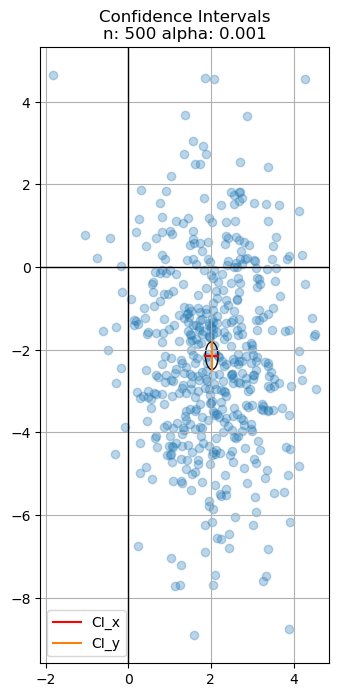

In [350]:
from matplotlib.patches import Ellipse
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(df.x, df.y, alpha=.3)
ax.axhline(c='black', linewidth=1)
ax.axvline(c='black', linewidth=1)

# Confidence Intervals
ax.plot(conf_ints[0], [x_bar[1]]*2, c='r', label='CI_x')
ax.plot([x_bar[0]]*2, conf_ints[1], c='tab:orange', label='CI_y')
## ellipse 
_xy = [conf_ints[i][0]+(conf_ints[i][1]-conf_ints[i][0])/2 for i in conf_ints]
_width = conf_ints[0][1] - conf_ints[0][0]
_height = conf_ints[1][1] - conf_ints[1][0]
_theta = 90-np.degrees(theta) if _ind!=0 else np.degrees(theta)*-1
ellipse = Ellipse(xy=_xy, width=_width, height=_height, angle=_theta,
                  edgecolor='black', alpha=0.95, facecolor="none", lw=1)
ax.add_patch(ellipse)

ax.set_aspect('equal')
ax.legend()
ax.grid(zorder=2)
ax.set_title(f"Confidence Intervals\nn: {len(df)} alpha: {alpha}");

#### CI = x_bar +/- z(s/sqrt(n))

In [172]:
# estimate number of samples needed to achieve a given significance value
alpha = 5e-2


In [15]:
ci - x_bar = z

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (1638937647.py, line 1)

In [ ]:
for i in conf_ints:
    print(i)
    print(conf_ints[i])

In [371]:
xb, z, s, n = 2, 1.5, .8, 10

xb + z*(s/np.sqrt(n))

np.float64(2.3794733192202053)

In [373]:
(z*s)/(np.sqrt(n)) + xb

np.float64(2.3794733192202058)

In [383]:
(z*s) + xb

3.2

In [384]:
np.sqrt(n)

np.float64(3.1622776601683795)

## n = (z*s)/(CI - x_bar)**2

In [363]:
alpha = 1e-3
deg_f = len(df) - 1
upper = stats.t.ppf(1 - alpha/2, df=deg_f)
lower = stats.t.ppf(alpha/2, df=deg_f)

In [370]:
precision = .001
((alpha * df.x.std())/((precision/2) - df.x.mean()))**2

np.float64(2.6116272973457116e-07)